In [57]:
%run -i ../python_scripts/nb_setup.py

GPU Available: False


#### Choose the dataset you want to use :
* must be data the model did not see at training
* first column : __y_true__ $\in \{0,1\}$ are the samples labels  
* second column : __y_pred__ are the predicted class of samples ($\in \{0,1\}$ too)
* third column : __kappa_f__ is confidence function for each sample, $\in \mathbb{R}$

In [ ]:
DATA = "WSI"  # or "CIFAR"
METRIC = "FPR"  # Choose metric among "standard" (0/1 risk), "FP" (risk), "FN" (risk), "FPR", "FNR", "SE", "PPV", "SP"
SEARCH_MODE = "multistart"  # or greedy

In [59]:
samples_SR = os.path.join(DATA, "sgp_set_cnn")
samples_MCD = os.path.join(DATA, "sgp_set_cnn_MCD")

In [60]:
sgp_df_SR = pickle.load(open(samples_SR, "rb"))
print(
    "N =",
    sgp_df_SR.shape[0],
    "Proportion of 1s: ",
    np.round(sgp_df_SR.y_true.sum() / sgp_df_SR.shape[0], 2),
)
sgp_df_SR.head(3)

N = 6788 Proportion of 1s:  0.33


,y_true,y_pred,kappa
0,0.0,0.0,0.996487
1,1.0,1.0,0.931987
2,1.0,1.0,0.947991


In [61]:
sgp_df_MCD = pickle.load(open(samples_MCD, "rb"))
sgp_df_MCD.head(3)

,y_true,y_pred,kappa
0,0.0,0.0,-0.000018
1,1.0,1.0,-0.001712
2,1.0,1.0,-0.000673


In [62]:
num_targets = 500  # number of targets r* to consider when drawing metric/coverage of metric/theta curves
theta_min_SR, theta_max_SR = 0.5, 1  # Sn-independent grids
theta_min_MCD, theta_max_MCD = (-0.07, 0)

Plot lines configuration (cosmetic) 

In [63]:
lines_list_1_SR, lines_list_2_SR, lines_list_1_MCD, lines_list_2_MCD, lines_list_2 = (
    lines()
)

In [64]:
# without prior one might just search over [0,1]
metric_targets = np.linspace(0, 1, num=num_targets)

In [65]:
train_set_SR, test_set_SR = train_test_split(
    sgp_df_SR, seed=42
)  # drawing 3/4 for bounds fitting, 1/4 for bounds testing
train_set_MCD, test_set_MCD = train_test_split(
    sgp_df_MCD, seed=42
)  # same with MCD kappa confidence function
results_SR = sgp_at_targets(
    train_set_SR,
    test_set_SR,
    metric=METRIC,
    mode=SEARCH_MODE,
    metric_targets=metric_targets,
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)
results_MCD = sgp_at_targets(
    train_set_MCD,
    test_set_MCD,
    metric=METRIC,
    mode=SEARCH_MODE,
    metric_targets=metric_targets,
    theta_min=theta_min_MCD,
    theta_max=theta_max_MCD,
)
all_results = {"SR": results_SR, "MCD": results_MCD}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

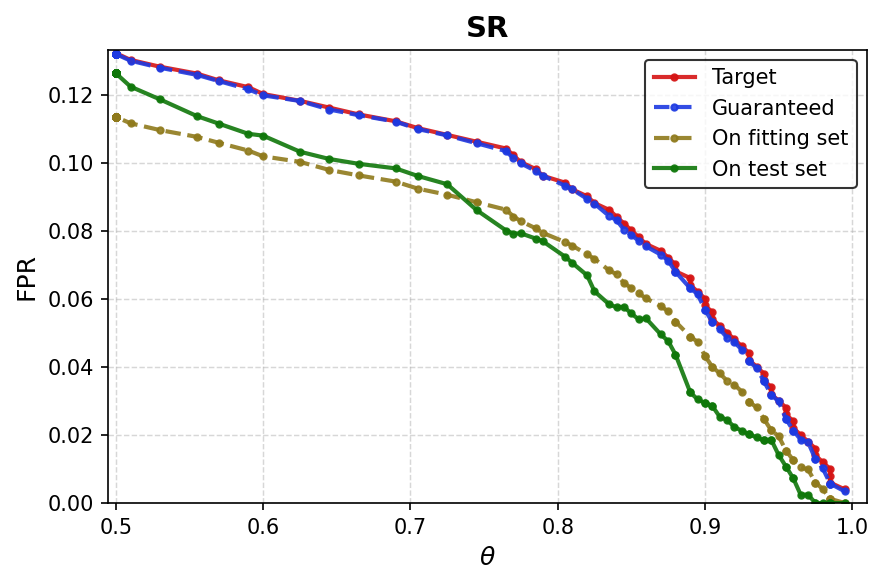

In [66]:
metric_plots(
    all_results,
    metric=METRIC,
    lines_list=lines_list_1_SR,
    xlim=[0.99 * theta_min_SR, 1.01 * theta_max_SR],
    ylim=[
        0.99 * min(min(results_SR.test_metric), min(results_SR.train_metric)),
        1.01 * max(results_SR.metric_bound),
    ],
    title="SR",
)

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

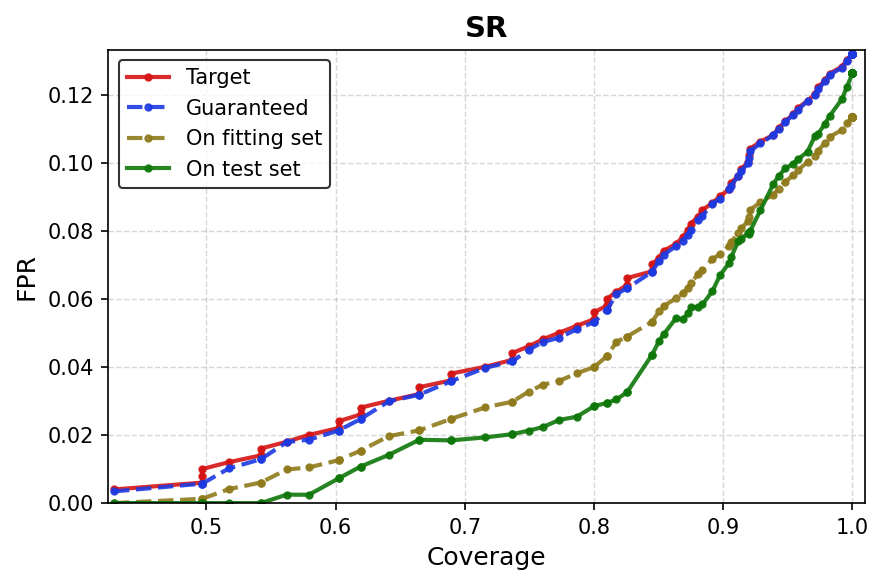

In [67]:
metric_plots(
    all_results,
    metric=METRIC,
    lines_list=lines_list_2_SR,
    xlim=[0.99 * min(results_SR.test_coverage), 1.01 * max(results_SR.test_coverage)],
    ylim=[
        0.99 * min(min(results_SR.test_metric), min(results_SR.train_metric)),
        1.01 * max(results_SR.metric_bound),
    ],
    title="SR",
)

Curves w.r.t. $\theta$, using Monte Carlo Dropout (MCD) minus variance as confidence function

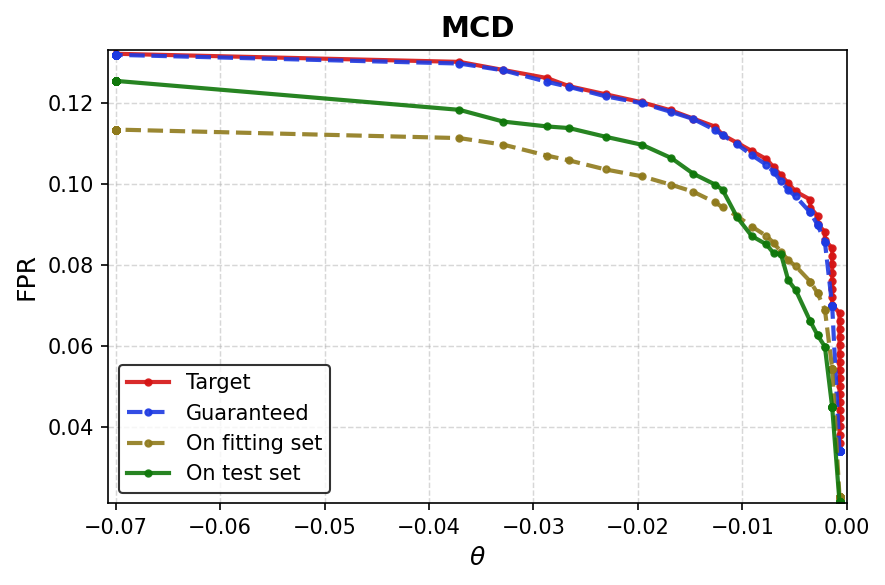

In [68]:
metric_plots(
    all_results,
    metric=METRIC,
    lines_list=lines_list_1_MCD,
    xlim=[1.01 * theta_min_MCD, 1.01 * theta_max_MCD],
    ylim=[
        0.99 * min(min(results_MCD.test_metric), min(results_MCD.train_metric)),
        1.01 * max(results_MCD.metric_bound),
    ],
    title="MCD",
)

Curves w.r.t. coverage, using Monte Carlo Dropout (MCD) minus variance as confidence function

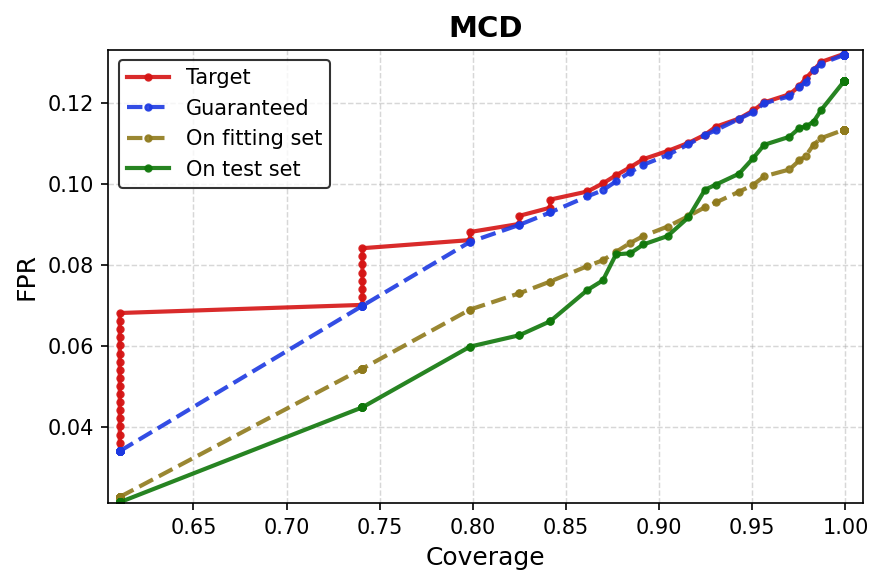

In [69]:
metric_plots(
    all_results,
    metric=METRIC,
    lines_list=lines_list_2_MCD,
    xlim=[0.99 * min(results_MCD.test_coverage), 1.01 * max(results_MCD.test_coverage)],
    ylim=[
        0.99 * min(min(results_MCD.test_metric), min(results_MCD.train_metric)),
        1.01 * max(results_MCD.metric_bound),
    ],
    title="MCD",
)

Bounds and test set estimates w.r.t. coverage, SR v. MCD 

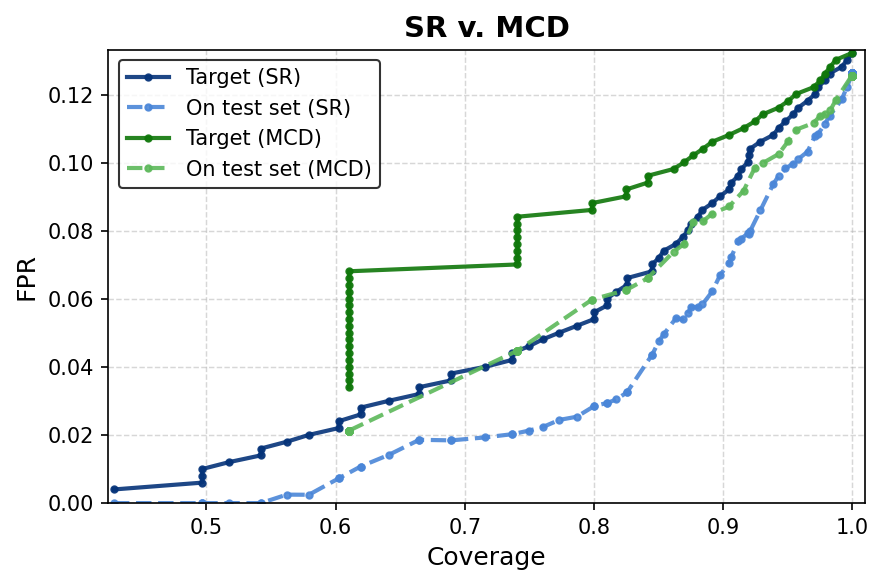

In [70]:
metric_plots(
    all_results,
    metric=METRIC,
    lines_list=lines_list_2,
    xlim=[
        0.99 * min(min(results_SR.test_coverage), min(results_MCD.test_coverage)),
        1.01 * max(max(results_MCD.test_coverage), max(results_SR.test_coverage)),
    ],
    ylim=[
        0.99 * min(min(results_MCD.test_metric), min(results_SR.test_metric)),
        1.01 * max(max(results_MCD.metric_bound), max(results_SR.metric_bound)),
    ],
    title="SR v. MCD",
)